# ```Seminar 1: Direct Linear Transformation```

## Theory

### Facts from linear algebra and geometry

**1. Inhomogeneous System of Linear Equations**  
Consider the system:  
$$
Ax = b, \quad b \neq 0, \quad A \in \mathbb{R}^{m \times n}
$$

*Case 1: Square matrix ($m = n$)*  

If the matrix $A$ is non-singular ($\det A \neq 0$), the solution is:  
$$ x = A^{-1}b $$

*Case 2: Rectangular matrix ($m \neq n$)*  

The problem reduces to solving:  
$$
\|Ax - b\|^2 \to \min_x \implies x = (A^* A)^{-1} A^* b = A^+ b
$$  
where:  
- $A^+$ is the Moore-Penrose pseudoinverse,  
- $A^*$ is the Hermitian conjugate (in $\mathbb{R}: A^* = A^T$).  

*Final solution:*  
$$
x = (A^T A)^{-1} A^T b
$$

**2. Homogeneous System of Linear Equations**  
Consider the system:  
$$
Ax = 0, \quad A \in \mathbb{R}^{m \times n}
$$

*How to find the solution?*  

The matrix $A$ is decomposed using SVD (Singular Value Decomposition):  
$$
A = U \Sigma V^T
$$  
where:  
- $U \in \mathbb{R}^{m \times m}$, $V^T \in \mathbb{R}^{n \times n}$ are orthogonal matrices ($U U^T = U^T U = I$, $V V^T = V^T V = I$),  
- $\Sigma = \text{diag}(\sigma_1, \ldots, \sigma_r, 0, \ldots, 0)$ is the diagonal matrix of singular values,  
- $\sigma_1 \geq \ldots \geq \sigma_r > 0$, $r = \text{rank}(A)$.  

*How to find a non-trivial solution?*  

The basis of the null space of $A$ consists of the last $(n - r)$ column-vectors of $V$.  

*General solution:*  
$$
x = c_1 v_{r+1} + \ldots + c_{n-r} v_n, \quad c_i \in \mathbb{R},  
$$  
where $v_i$ are the columns of $V$, and $c_i$ are arbitrary constants.  

*Note:* In the complex case, $V^T$ is replaced by $V^*$ (the Hermitian conjugate).  

### Forward imaging model: 3D to 2D

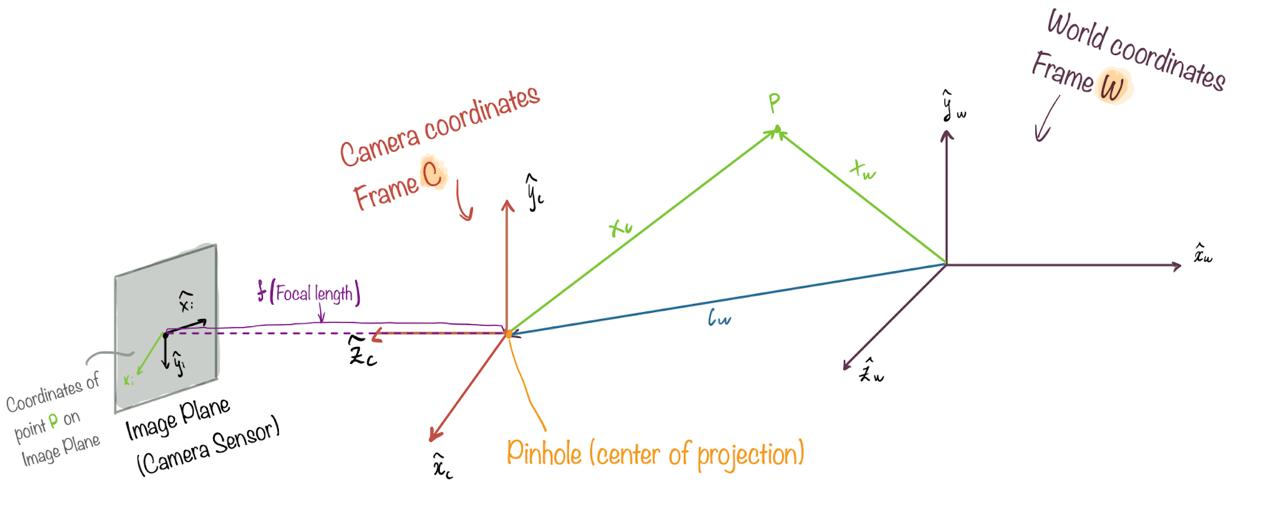

$f$ (focal length) — the distance from the projection center to the camera sensor  

$X_w$ — coordinates of point $P$ in the W (world) coordinate system  

$X_c$ — coordinates of point $P$ in the camera coordinate system  

$C_w$ — coordinates of the camera's projection center in the W coordinate system  

$X_i$ — coordinates of point $P$ in the Image plane coordinate system  

**What are we going to do?**  

**Image Coordinates**  

$X_i = \begin{bmatrix} x_i \\ y_i \end{bmatrix}$  

**Camera Coordinates**  

$X_c = \begin{bmatrix} x_c \\ y_c \\ w_c \end{bmatrix}$  

**World Coordinates**  

$X_w = \begin{bmatrix} x_w \\ y_w \\ z_w \end{bmatrix}$  

**Transformation Sequence:**  

$$
\begin{array}{ccccc}  
X_w & \xrightarrow{\text{Coordinate transformation}} & X_c & \xrightarrow{\text{Perspective Projection}} & X_i \\  
\end{array}
$$

### Perspective projection

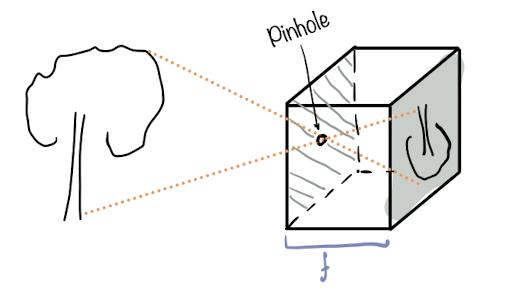

Let’s select the **OYZ** axis in the camera’s basis:  

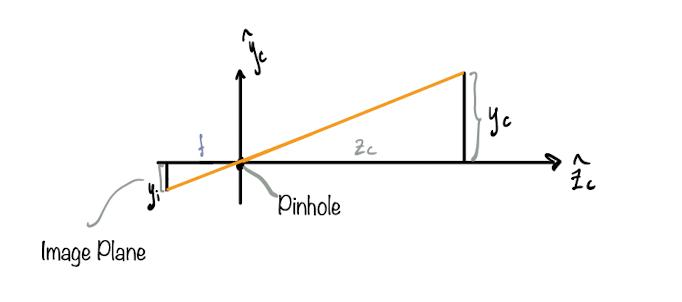

We have:  
$$ \frac{y_i}{f} = \frac{y_c}{z_c} \Rightarrow y_i = f \frac{y_c}{z_c} $$  

Similarly for **oXZ**:  
$$ x_i = f \frac{x_c}{z_c} $$  

### Image plane to Image Sensor Mapping


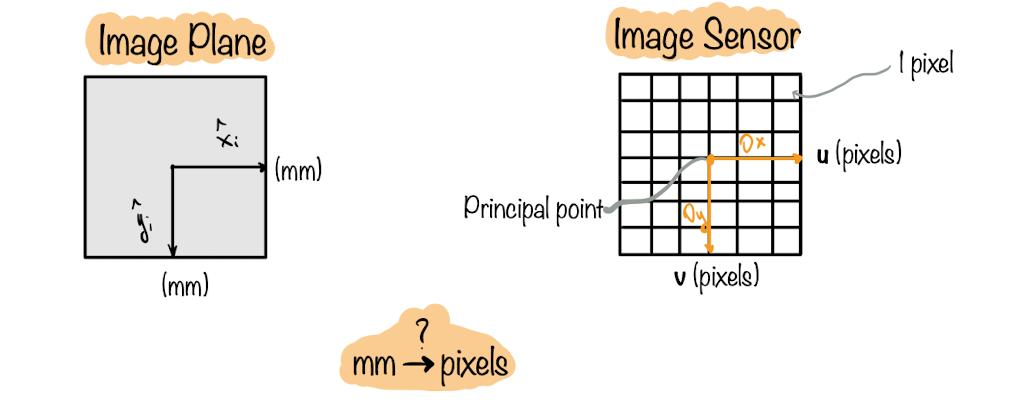

**Task:** Convert coordinates from physical units (mm) to pixel coordinates (`mm` $\implies$ `pixels`).  
*Note:* Pixels are not necessarily square; they can be rectangular:

- $m_x, m_y$ — pixel densities along the $x$ and $y$ axes, respectively,  
  $[m_x] = [m_y] = \text{pixels/mm}$.

Coordinates of a point on the sensor in mm: $x_i, y_i$.

Pixel coordinates:
$$
\begin{aligned}
u &= m_x \cdot x_i = m_x \cdot f \frac{x_c}{z_c} \\
v &= m_y \cdot y_i = m_y \cdot f \frac{y_c}{z_c}
\end{aligned}
$$

Typically, the coordinate system is shifted to the top-left corner.


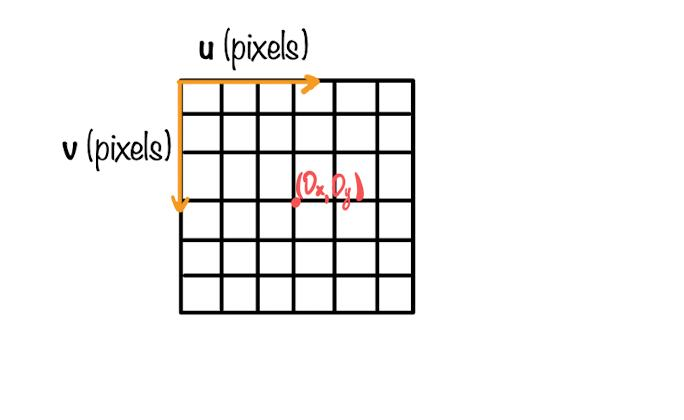

- $(O_x, O_y)$ — principal point — the point where the optical axis intersects the sensor.

*Note:* The exact position of the principal point is typically unknown due to measurement errors and is determined through calibration using known images.

Thus:

$$
\begin{cases}
u = m_x f \dfrac{x_c}{z_c} + O_x \\
v = m_y f \dfrac{y_c}{z_c} + O_y
\end{cases}
$$

where $O_x, O_y$ are unknown offset parameters.

### Perspective projection

$$U = \mathbf{m_x f} \frac{x_c}{z_c} + \mathbf{O_x} \quad V = \mathbf{m_y f} \frac{y_c}{z_c} + \mathbf{O_y}$$

**Bold** marks unknown parameters.

The focal lengths expressed in pixels are defined as:
$$
f_x = m_x f, \quad f_y = m_y f
$$

Then the equations become:
$$
\begin{aligned}
U &= f_x \frac{x_c}{z_c} + O_x \\
V &= f_y \frac{y_c}{z_c} + O_y
\end{aligned}
$$

**Camera Intrinsic Parameters**  
$(f_x, f_y, O_x, O_y)$ - intrinsic parameters describing internal geometry:
- $f_x, f_y$ - focal lengths
- $O_x, O_y$ - principal point offset

Note: We get a nonlinear model (due to division). A linear model would be more convenient.

### Homogeneous coordinates


$\widetilde{u}=(\widetilde{u}, \widetilde{v}, \widetilde{w})$

We define the **homogeneous representation** of a 2D point $u=(u,v)$ as a 3D point $\widetilde{u}=(\widetilde{u}, \widetilde{v}, \widetilde{w})$ where $\widetilde{w} \neq 0$ and:
$$ u = \frac{\widetilde{u}}{\widetilde{w}}, \quad v = \frac{\widetilde{v}}{\widetilde{w}} $$

$$a = \begin{bmatrix} u \\ v \\ 1 \end{bmatrix} = \begin{bmatrix} \widetilde{w}u \\ \widetilde{w}v \\ \widetilde{w} \end{bmatrix} = \widetilde{a}$$

Every point on line L (except the origin) represents the homogeneous coordinate $a(u,v)$ (they define an equivalence class).

The same applies for 3D $\implies$ 4D conversion.


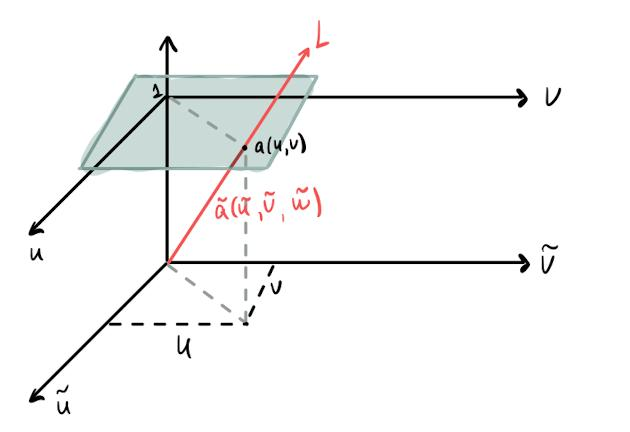

### Perspective projection and hom coordinates

*Original system of equations (it's not linear):*
$$
\begin{cases}
U = f_x \dfrac{x_c}{z_c} + O_x \\
V = f_y \dfrac{y_c}{z_c} + O_y
\end{cases}
$$

*Conversion to homogeneous coordinates:*
$$
\begin{bmatrix} u \\ v \\ 1 \end{bmatrix} \rightarrow
\begin{bmatrix} \widetilde{u} \\ \widetilde{v} \\ \widetilde{w} \end{bmatrix} =
\begin{bmatrix} z_c u \\ z_c v \\ z_c \end{bmatrix} =
\begin{bmatrix}
f_x x_c + z_c O_x \\
f_y y_c + z_c O_y \\
z_c
\end{bmatrix}
$$

*Projection matrix form:*
$$
= \underbrace{
\begin{bmatrix}
f_x & \mathbf{0} & O_x & 0 \\
0 & f_y & O_y & 0 \\
0 & 0 & 1 & 0
\end{bmatrix}
}_{M_{int} \text{ (3×4 intrinsic matrix)}}
\underbrace{
\begin{bmatrix} x_c \\ y_c \\ z_c \\ 1 \end{bmatrix}
}_{\text{3D point in homogeneous coordinates}}
$$

*Notes:*
- The **bold** `0` may be replaced with parameter $\gamma$ (axis shift coefficient)
- In modern cameras $\gamma = 0$ (axes are strictly orthogonal)

*Final projection pipeline:*
$$
\begin{cases}
U = f_x \frac{x_c}{z_c} + O_x \\
V = f_y \frac{y_c}{z_c} + O_y
\end{cases}
\Rightarrow
\begin{bmatrix} u \\ v \\ 1 \end{bmatrix}
= \begin{bmatrix} \widetilde{u} \\ \widetilde{v} \\ \widetilde{w} \end{bmatrix}
= \begin{bmatrix} z_c u \\ z_c v \\ z_c \end{bmatrix}
= \begin{bmatrix} f_x x_c + z_c O_x \\ f_y y_c + z_c O_y \\ z_c \end{bmatrix}
= \begin{bmatrix} f_x & 0 & O_x & 0 \\ 0 & f_y & O_y & 0 \\ 0 & 0 & 1 & 0 \end{bmatrix}
\begin{bmatrix} x_c \\ y_c \\ z_c \\ 1 \end{bmatrix}
$$

*Result:* A linear model for perspective projection!

$$ M_{int} = \begin{bmatrix} f_x & 0 & O_x & 0 \\ 0 & f_y & O_y & 0 \\ 0 & 0 & 1 & 0 \end{bmatrix} \text{ (intrinsic matrix)} \quad M_{int} = [K|0] $$

$$ K = \begin{bmatrix} f_x & 0 & O_x \\ 0 & f_y & O_y \\ 0 & 0 & 1 \end{bmatrix} \text{ (upper-triangular calibration matrix)} $$

$$ \underbrace{\widetilde{u}}_{\text{pixel coords}} = [K|0] \underbrace{\widetilde{X}_c}_{\text{camera coords (homogeneous)}} = M_{int} \underbrace{\widetilde{X}_c}_{\text{homogeneous}} $$

### Coordinate transformation

Let's go back to the first picture

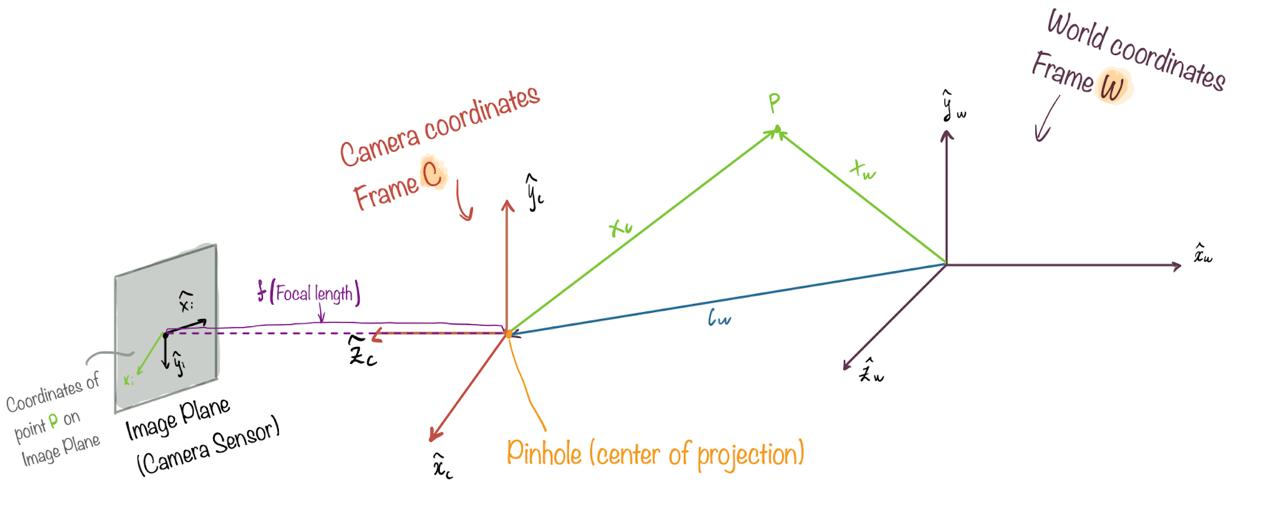

The position $c_w$ and orientation $R$ of the camera in world coordinates are the **extrinsic parameters**.

$$ R = \begin{bmatrix} r_{11} & r_{12} & r_{13} \\ r_{21} & r_{22} & r_{23} \\ r_{31} & r_{32} & r_{33} \end{bmatrix} \begin{array}{l} \rightarrow \text{Row 1: direction of } \widehat{x}_c \text{ in world coordinates} \\ \rightarrow \text{Row 2: } -\|- \text{ } \widehat{y}_c \text{ } -\|- \\ \rightarrow \text{Row 3: } -\|- \text{ } \widehat{z}_c \text{ } -\|- \end{array} $$
where $R^T R = R R^T = I$ — orthogonal.

$(R, C_w)$ - **extrinsic parameters**.

$X_c = R(X_w - C_w)$ — simply the vector difference.

$X_c = R(X_w - C_w) = R X_w + \underbrace{t}_{translation \atop vector}, \quad t = -RC_w$.

$$ X_c = \begin{bmatrix} r_{11} & r_{12} & r_{13} \\ r_{21} & r_{22} & r_{23} \\ r_{31} & r_{32} & r_{33} \end{bmatrix} \begin{bmatrix} x_w \\ y_w \\ z_w \end{bmatrix} + \begin{bmatrix} t_x \\ t_y \\ t_z \end{bmatrix} $$

Or in homogeneous coordinates:
$$ \widetilde{X}_c = \begin{bmatrix} x_c \\ y_c \\ z_c \\ 1 \end{bmatrix} = \underbrace{\begin{bmatrix} r_{11} & r_{12} & r_{13} & t_x \\ r_{21} & r_{22} & r_{23} & t_y \\ r_{31} & r_{32} & r_{33} & t_z \\ 0 & 0 & 0 & 1 \end{bmatrix}}_{M_{\text{ext}} = \begin{bmatrix} R_{3 \times 3} & t \\ 0_{1 \times 3} & 1 \end{bmatrix}_{4 \times 4} \text{ - extrinsic matrix}} \begin{bmatrix} x_w \\ y_w \\ z_w \\ 1 \end{bmatrix} $$

$$ \widetilde{X}_c = M_{ext} \widetilde{X}_w $$


### Projection matrix

$$ \underbrace{\widetilde{u}}_{\substack{\text{projection} \\ \text{in pixels} \\ \text{in image}}} = M_{int} \cdot M_{ext} \cdot \widetilde{X}_w = \underbrace{P}_{\substack{\mathbb{R}^{3 \times 4} \\ \text{projection matrix}}} \widetilde{X}_w $$

$ \widetilde{X}_w$ - any 3D point in World coordinates.

To calibrate the camera we need only P (this 12 members)

### Camera Calibration with DLT (Direct Linear Transformation)

**Task:** Find the camera projection matrix $P_{3\times4}$ using $n \geq 6$ correspondences between 3D world points and 2D image pixels.

*Projective Transformation:*

$$
\widetilde{u} = P \widetilde{X}_w \quad \text{where} \quad P = \begin{bmatrix} P_1 \\ P_2 \\ P_3 \end{bmatrix}
$$

*Expanded matrix form:*
$$
\begin{bmatrix} \widetilde{u} \\ \widetilde{v} \\ \widetilde{w} \end{bmatrix} =
\underbrace{P_{3 \times 4}}_{\begin{bmatrix} P_1 \\ P_2 \\ P_3 \end{bmatrix}}
\begin{bmatrix} \widetilde{x}_w \\ \widetilde{y}_w \\ \widetilde{z}_w \\ \widetilde{\omega}_w \end{bmatrix}
\Rightarrow
\begin{cases}
\widetilde{u} = P_1 \widetilde{X}_w \\
\widetilde{v} = P_2 \widetilde{X}_w \\
\widetilde{w} = P_3 \widetilde{X}_w
\end{cases}
$$

*Conversion to pixel coordinates:*
$$
\begin{cases}
u = \dfrac{\widetilde{u}}{\widetilde{w}} \\
v = \dfrac{\widetilde{v}}{\widetilde{w}}
\end{cases}
\Rightarrow
\begin{cases}
u\widetilde{w} - \widetilde{u} = 0 \\
v\widetilde{w} - \widetilde{v} = 0
\end{cases}
\Rightarrow
\begin{cases}
u P_3 \widetilde{X}_w - P_1 \widetilde{X}_w = 0 \\
v P_3 \widetilde{X}_w - P_2 \widetilde{X}_w = 0
\end{cases}
$$

*Final system of equations:*
$$
\begin{bmatrix}
-\widetilde{X}_w^T & \mathbf{0}^T & u \widetilde{X}_w^T \\
\mathbf{0}^T & -\widetilde{X}_w^T & v \widetilde{X}_w^T
\end{bmatrix}
\underbrace{\begin{bmatrix} P_1^T \\ P_2^T \\ P_3^T \end{bmatrix}}_{\in \mathbb{R}^{12 \times 1}} = \mathbf{0}
$$

*Notes:*
1. Transposing $P_1, P_2, P_3$ are necessary for dimension consistency  
2. Minimum **6 points** → 12 equations required for solving  

$$
\begin{bmatrix}
-\widetilde{x}_w & -\widetilde{y}_w & -\widetilde{z}_w & -1 & 0 & 0 & 0 & 0 & u\widetilde{x}_w & u\widetilde{y}_w & u\widetilde{z}_w & u \\
0 & 0 & 0 & 0 & -\widetilde{x}_w & -\widetilde{y}_w & -\widetilde{z}_w & -1 & v\widetilde{x}_w & v\widetilde{y}_w & v\widetilde{z}_w & v
\end{bmatrix}
\begin{bmatrix} P_1^T \\ P_2^T \\ P_3^T \end{bmatrix} = 0
$$


6 points $\Rightarrow B_{12 \times 12} \cdot P_{12 \times 1} = 0$

$$ \text{SVD}(B) = U \Sigma V^T,$$
where the last column of $V$ is the solution that corresponds to the smallest singular value.

**Why is the rank of matrix $B = 11$?**

The projection matrix P is defined only **up to a scale factor**. This means that for any non-zero scalar $\lambda \neq 0$, the matricws $P$ and $\lambda P$ represent the **same** camera preojection, because the physical pixel coordinates are unchanged: $x = \lambda u / \lambda w = u / w,\quad y = \lambda v / \lambda w = v / w$.

So, in $P$  we lose 1 degree of freedom due to this scale ambiguity. Therefore, we only need to solve for 11 unknowns, which corresponds to the rank of B being 11.

**DLT for the 2D case:**

Here we need **homography matrix** $H$ (rotation, scaling, translation) to translate 2D-to-2D:
$$
\begin{bmatrix} \widetilde{u_l} \\ \widetilde{v_l} \\ \widetilde{w_l} \end{bmatrix} =
H_{3 \times 3}
\begin{bmatrix} \widetilde{u_r} \\ \widetilde{v_r} \\ \widetilde{w_r} \end{bmatrix}.
$$

$H \in \mathbb{R}^{3 \times 3}$ contains **9 elements**, $H$ is defined up to scale (as $P: H \sim \lambda H$), so we lose 1 degree of freedom.


Each point correspondence provides 2 linearly independent equations, so at least 4 points are required to solve the system $B_{8\times9} \cdot \mathbf{h} = 0$

## Practice

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Toy-example for points

In [2]:
def to_homogeneous(points):
    """
    Converts 2D Cartesian coordinates to homogeneous coordinates by appending a 1.

    Parameters:
    points: Array-like of shape (N, 2) representing N 2D points. Each row is a point [x, y].

    Returns:
    Array of shape (N, 3) representing points in homogeneous coordinates. Each row is a point [x, y, 1].
    """
    return np.hstack([points, np.ones((points.shape[0], 1))])

def dlt(source_points, transformed_points):
    """
    Computes the homography matrix H (3x3) that maps source_points to transformed_points
    using the Direct Linear Transformation (DLT) algorithm.

    Requires exactly 4 point correspondences.

    Parameters:
    source_points: Array-like of shape (4, 2) of 4 source points.
    transformed_points: Array-like of shape (4, 2) of 4 corresponding transformed points.

    Returns:
    3x3 homography matrix H, normalized such that H[2,2] = 1.

    Raises:
    AssertionError: If incorrect number of points is provided.
    """
    n = source_points.shape[0]
    assert n <= 4, "At least 4 point correspondences are required to estimate homography!"

    source_points_h = to_homogeneous(source_points)
    transformed_points_h = to_homogeneous(transformed_points)

    A = []
    for i in range(n):
        x, y, w = source_points_h[i]
        u, v, s = transformed_points_h[i]
        A.append([-w*x, -w*y, -w, 0, 0, 0, u*x, u*y, u])
        A.append([0, 0, 0, -w*x, -w*y, -w, v*x, v*y, v])
    A = np.array(A)

    U, S, Vt = np.linalg.svd(A)
    H = Vt[-1, :].reshape((3, 3))
    H /= H[2, 2]
    return H

def apply_H(H, points):
    """
    Applies a 3x3 homography matrix to a set of 2D points.

    Transformation steps:
    1. Convert to homogeneous coordinates
    2. Apply homography matrix H
    3. Perform perspective division
    4. Convert back to Cartesian coordinates

    Parameters:
    H: 3x3 homography matrix
    points: Array-like of shape (N, 2) representing N 2D points

    Returns:
    Transformed points in Cartesian coordinates, shape (N, 2). Each row is a point [x', y'].
    """
    points_h = to_homogeneous(points)
    transformed = (H @ points_h.T).T
    transformed /= transformed[:, [2]]
    return transformed[:, :2]

In [3]:
# It's important that these points are non-collinear, i.e., they form a polygon with non-zero area.
src_points = np.array([
    [100, 200],
    [200, 200],
    [200, 300],
    [100, 300]
], dtype=np.float64)

dst_points = np.array([
    [150, 250],
    [250, 230],
    [240, 340],
    [140, 360]
], dtype=np.float64)

H_computed = dlt(src_points, dst_points)
print("Estimated Homography Matrix H:")
print(H_computed)

mapped_points = apply_H(H_computed, src_points)

assertion_passed = np.allclose(mapped_points, dst_points, atol=1e-9)
assert assertion_passed, \
    f"Assertion failed: Mapped points do not closely match destination points.\n" \
    f"Mapped points:\n{mapped_points}\n" \
    f"Destination points:\n{dst_points}\n" \
    f"Difference:\n{mapped_points - dst_points}"

print("\nAssertion successful: Transformed source points closely match destination points.")

# print("\nSource points:\n", src_points)
# print("\nTransformed points (after applying H):\n", mapped_points)
# print("\nDestination (target) points:\n", dst_points)

Estimated Homography Matrix H:
[[ 1.00000000e+00 -1.00000000e-01  7.00000000e+01]
 [-2.00000000e-01  1.10000000e+00  5.00000000e+01]
 [ 7.46297112e-16 -2.68666960e-15  1.00000000e+00]]

Assertion successful: Transformed source points closely match destination points.


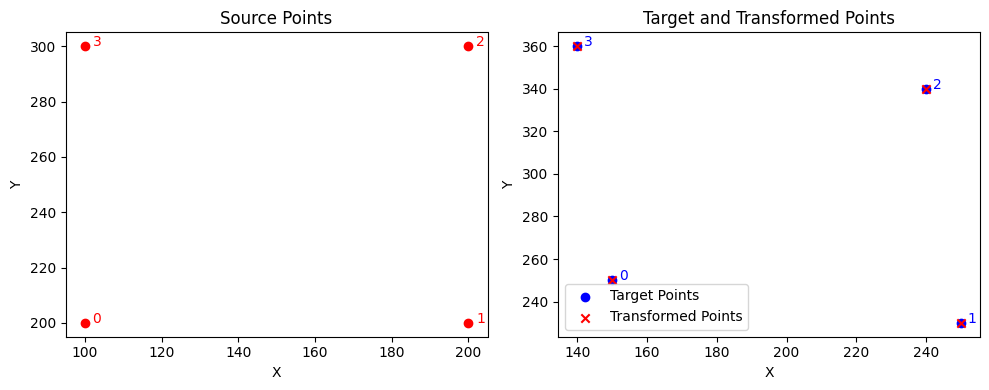

In [4]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title("Source Points")
plt.scatter(src_points[:, 0], src_points[:, 1], color='red')
for i, pt in enumerate(src_points):
    plt.text(pt[0] + 2, pt[1], f"{i}", color='red')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(1, 2, 2)
plt.title("Target and Transformed Points")
plt.scatter(dst_points[:, 0], dst_points[:, 1], color='blue', label='Target Points')
plt.scatter(mapped_points[:, 0], mapped_points[:, 1], color='red', marker='x', label='Transformed Points')
for i, pt in enumerate(dst_points):
    plt.text(pt[0] + 2, pt[1], f"{i}", color='blue')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.tight_layout()
plt.show()

### Real example (forward and inverse homography)

In [5]:
!wget -O dollar.jpeg https://raw.githubusercontent.com/struminsky/hse_3dcv/main/week_01/seminar/dollar.jpeg

--2026-01-22 13:22:50--  https://raw.githubusercontent.com/struminsky/hse_3dcv/main/week_01/seminar/dollar.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1958617 (1.9M) [image/jpeg]
Saving to: ‘dollar.jpeg’

dollar.jpeg         100%[===================>]   1.87M  --.-KB/s    in 0.04s   

2026-01-22 13:22:50 (47.2 MB/s) - ‘dollar.jpeg’ saved [1958617/1958617]



In [6]:
from PIL import Image

img_path = './dollar.jpeg'
img = Image.open(img_path)

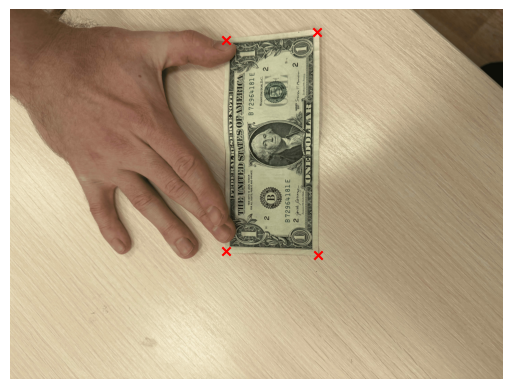

In [7]:
plt.imshow(img)
plt.scatter([2500, 2500, 3570, 3560], [2800, 350, 2850, 260], marker='x', c='red')
plt.axis('off')
plt.show()

In [8]:
src_points = np.array([
    [2500, 2800],   # bottom left
    [2500, 350],    # top left
    [3570, 2850],   # bottom right
    [3560, 260]     # top right
], dtype=np.float64)

dst_points = np.array([
    [0, 0],         # Destination coordinate for src_points[0]
    [1000, 0],      # Destination coordinate for src_points[1]
    [0, 420],       # Destination coordinate for src_points[2]
    [1000, 420]     # Destination coordinate for src_points[3]
], dtype=np.float64)

In [9]:
H = dlt(src_points, dst_points)
print("Estimated Homography Matrix H:\n", H)

mapped_points = apply_H(H, src_points)
assertion_passed = np.allclose(mapped_points, dst_points, atol=0.0000001)

assert assertion_passed, \
    f"Assertion failed: Mapped points do not closely match destination points.\n" \
    f"Source points:\n{src_points}\n" \
    f"Mapped points (H @ src_points):\n{mapped_points}\n" \
    f"Expected destination points:\n{dst_points}\n" \
    f"Difference (Mapped - Destination):\n{mapped_points - dst_points}"

print("\nAssertion successful: Transformed source points closely match the destination points.")

Estimated Homography Matrix H:
 [[ 2.20847059e-02 -4.72612706e-01  1.26810381e+03]
 [ 4.84920138e-01  3.55307669e-12 -1.21230034e+03]
 [ 6.25701811e-05  4.21622244e-06  1.00000000e+00]]

Assertion successful: Transformed source points closely match the destination points.


**Comparison of Forward vs Inverse Warping**

*Forward Warping:*  
Maps source pixels → destination. Can create holes (unfilled pixels) when multiple source pixels map to the same destination or when gaps appear due to geometric expansion. The holes can appear as black spots/artifacts in the output.

*Inverse Warping:*  
Maps destination pixels → source. Guarantees every output pixel is filled by computing its source location using H^(-1). This eliminates holes.

*Note:*  
Visual differences may be subtle in this example due to image content and transformation type, but the difference map reveals the artifacts. Forward warping typically shows more problems with large rotations or significant scale changes.

*Best Practice:*  
Always use inverse warping for image transformations.


In [10]:
def create_output_canvas(image, output_size):
    """
    Creates empty output canvas for warped image.
    Parameters:
        image: Input image array
        output_size: Tuple (width, height) for output dimensions
    Returns:
        Empty array with shape (height, width, channels) matching output size
        and dtype matching input image
    """
    height, width = output_size[1], output_size[0]
    return np.zeros((height, width, image.shape[2]), dtype=image.dtype)

def inverse_warping(image, H, output_size):
    """
    Performs inverse warping by mapping output pixels to source image.

    Parameters:
        image: Source image array
        H: 3x3 homography matrix
        output_size: Tuple (width, height) for output dimensions
    Returns:
        Warped image using inverse mapping approach
    """
    warped = create_output_canvas(image, output_size)
    H_inv = np.linalg.inv(H)

    y_coords, x_coords = np.indices((output_size[1], output_size[0]))
    output_coords = np.stack([x_coords.ravel(), y_coords.ravel()], axis=-1)

    src_coords = apply_H(H_inv, output_coords)
    src_coords = np.round(src_coords).astype(int)

    valid_mask = ((src_coords[:, 0] >= 0) & (src_coords[:, 0] < image.shape[1]) &  (src_coords[:, 1] >= 0) & (src_coords[:, 1] < image.shape[0]))

    warped[output_coords[valid_mask][:, 1], output_coords[valid_mask][:, 0]] = image[src_coords[valid_mask][:, 1], src_coords[valid_mask][:, 0]]

    return warped

def forward_warping(image, H, output_size):
    """
    Performs forward warping by mapping source pixels to output image.

    Parameters:
        image: Source image array
        H: 3x3 homography matrix
        output_size: Tuple (width, height) for output dimensions

    Returns:
        Warped image using forward mapping approach
    """
    warped = create_output_canvas(image, output_size)
    y_coords, x_coords = np.indices((image.shape[0], image.shape[1]))
    src_coords = np.stack([x_coords.ravel(), y_coords.ravel()], axis=-1)
    dest_coords = apply_H(H, src_coords)
    dest_coords = np.round(dest_coords).astype(int)
    valid_mask = ((dest_coords[:, 0] >= 0) & (dest_coords[:, 0] < output_size[0]) & (dest_coords[:, 1] >= 0) & (dest_coords[:, 1] < output_size[1]))

    for src, dest in zip(src_coords[valid_mask], dest_coords[valid_mask]):
        warped[dest[1], dest[0]] = image[src[1], src[0]]

    return warped

def warp_image_with_homography(image, H, output_size, use_inverse_mapping=True):
    """
    Warps an image using homography transformation with choice of mapping method.

    Parameters:
        image: Source image array (H,W,C) or (H,W)
        H: 3x3 homography matrix
        output_size: Tuple (width, height) for output dimensions
        use_inverse_mapping: Boolean (default True) to select mapping method

    Returns:
        Warped image array
    """
    if use_inverse_mapping:
        return inverse_warping(image, H, output_size)
    else:
        return forward_warping(image, H, output_size)

Arrays are nearly identical: False
Maximum difference: 255
Mean difference: 111.62855158730159


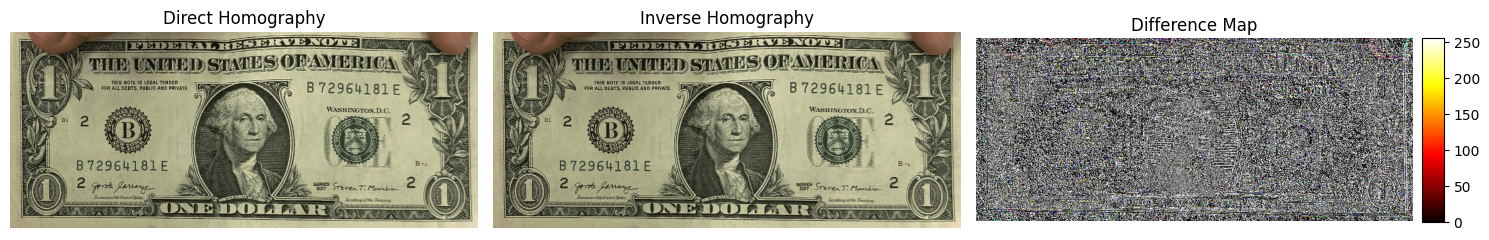

In [11]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

transformed_img_direct = warp_image_with_homography(np.array(img), H, (1000, 420), False)
transformed_img_inverse = warp_image_with_homography(np.array(img), H, (1000, 420), True)
difference = np.abs(transformed_img_direct - transformed_img_inverse)

are_close = np.allclose(transformed_img_direct, transformed_img_inverse)
print("Arrays are nearly identical:", are_close)
print("Maximum difference:", np.max(difference))
print("Mean difference:", np.mean(difference))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(transformed_img_direct)
axes[0].set_title('Direct Homography')
axes[0].axis('off')

axes[1].imshow(transformed_img_inverse)
axes[1].set_title('Inverse Homography')
axes[1].axis('off')

im_diff = axes[2].imshow(difference, cmap='hot')
axes[2].set_title('Difference Map')
axes[2].axis('off')

divider = make_axes_locatable(axes[2])
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_diff, cax=cax)

plt.tight_layout()
plt.show()

Let's make another transformation where we can see mentioned "holes".

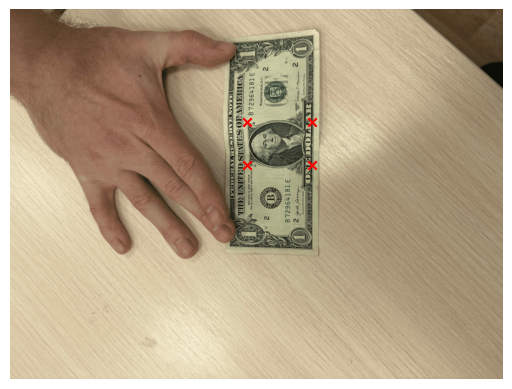

In [12]:
 plt.imshow(img)
plt.scatter([2750, 2750, 3500, 3500], [1800, 1300, 1800, 1300], marker='x', c='red')
plt.axis('off')
plt.show()

In [14]:
src_points = np.array([
    [2750, 1800],       # bottom left
    [2750, 1300],       # top left
    [3500, 1800],       # bottom right
    [3500, 1300]        # top right
], dtype=np.float64)

dst_points = np.array([
    [0, 0],         # Destination coordinate for src_points[0]
    [750, 0],       # Destination coordinate for src_points[1]
    [0,500],        # Destination coordinate for src_points[2]
    [750, 500]      # Destination coordinate for src_points[3]
], dtype=np.float64)

In [15]:
H = dlt(src_points, dst_points)
print("Estimated Homography Matrix H:\n", H)

mapped_points = apply_H(H, src_points)
assertion_passed = np.allclose(mapped_points, dst_points, atol=0.0000001)

assert assertion_passed, \
    f"Assertion failed: Mapped points do not closely match destination points.\n" \
    f"Source points:\n{src_points}\n" \
    f"Mapped points (H @ src_points):\n{mapped_points}\n" \
    f"Expected destination points:\n{dst_points}\n" \
    f"Difference (Mapped - Destination):\n{mapped_points - dst_points}"

print("\nAssertion successful: Transformed source points closely match the destination points.")

Estimated Homography Matrix H:
 [[ 3.14369516e-11 -1.50000000e+00  2.70000000e+03]
 [ 6.66666667e-01  7.71316149e-11 -1.83333334e+03]
 [ 2.82718733e-13  2.34419475e-14  1.00000000e+00]]

Assertion successful: Transformed source points closely match the destination points.


Arrays are nearly identical: False
Maximum difference: 255
Mean difference: 90.17945422222222


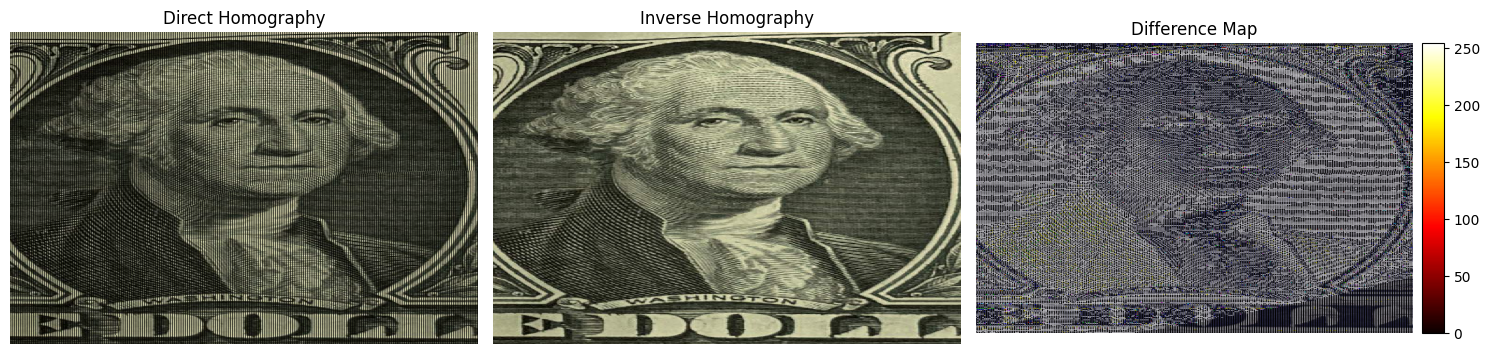

In [16]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

transformed_img_direct = warp_image_with_homography(np.array(img), H, (750, 500), False)
transformed_img_inverse = warp_image_with_homography(np.array(img), H, (750, 500), True)
difference = np.abs(transformed_img_direct - transformed_img_inverse)

are_close = np.allclose(transformed_img_direct, transformed_img_inverse)
print("Arrays are nearly identical:", are_close)
print("Maximum difference:", np.max(difference))
print("Mean difference:", np.mean(difference))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(transformed_img_direct)
axes[0].set_title('Direct Homography')
axes[0].axis('off')

axes[1].imshow(transformed_img_inverse)
axes[1].set_title('Inverse Homography')
axes[1].axis('off')

im_diff = axes[2].imshow(difference, cmap='hot')
axes[2].set_title('Difference Map')
axes[2].axis('off')

divider = make_axes_locatable(axes[2])
cax = divider.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im_diff, cax=cax)

plt.tight_layout()
plt.show()